In [77]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from mpl_toolkits.mplot3d import Axes3D
cont684_data = pd.read_csv('trans_c09_continuo_6840.txt',sep=r'\s+')  
cont684_data

,Wavelength(nm),Transmission(%)
0,710.0,0.0
1,709.8,0.0
2,709.6,0.0
3,709.4,0.0
4,709.2,0.0
...,...,...
246,660.8,0.0
247,660.6,0.0
248,660.4,0.0
249,660.2,0.0


In [79]:
cont4430_data = pd.read_csv('trans_c03_continuo_4430.txt',sep=r'\s+')
cont4430_data

,Wavelength(nm),Transmission(%)
0,450.0,0.032
1,449.8,0.039
2,449.6,0.046
3,449.4,0.055
4,449.2,0.066
...,...,...
66,436.8,0.044
67,436.6,0.036
68,436.4,0.029
69,436.2,0.025


In [81]:
H2O_data = pd.read_csv('trans_c10_h2o_7000.txt',sep=r'\s+')
H2O_data

,Wavelength(nm),Transmission(%)
0,740.0,0.000
1,739.8,0.001
2,739.6,0.000
3,739.4,0.000
4,739.2,0.000
...,...,...
346,670.8,0.000
347,670.6,0.000
348,670.4,0.000
349,670.2,0.000


In [83]:
CO_data = pd.read_csv('trans_c07_co_4260.txt',sep=r'\s+')
CO_data

,Wavelength(nm),Transmission(%)
0,450.0,0.0
1,449.8,0.0
2,449.6,0.0
3,449.4,0.0
4,449.2,0.0
...,...,...
196,410.8,0.0
197,410.6,0.0
198,410.4,0.0
199,410.2,0.0


In [85]:
R_data = pd.read_csv('trans_R.txt',sep=r'\s+')
R_data

,Wavelength(nm),Transmission(%)
0,1100.0,0.045
1,1099.8,0.048
2,1099.6,0.042
3,1099.4,0.044
4,1099.2,0.050
...,...,...
3496,400.8,0.000
3497,400.6,0.000
3498,400.4,0.000
3499,400.2,0.000


/var/folders/xk/35xssqr514g4r9k0tm7wppxw0000gn/T/ipykernel_5469/4135546703.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  h2o_lines_data = pd.read_csv(file_path, delim_whitespace=True, header=None, usecols=[0])


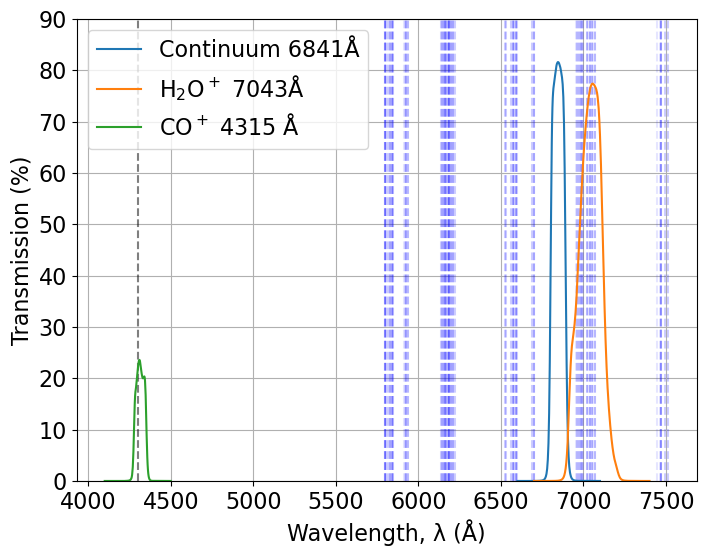

In [89]:

file_path = "h20+ lines.txt"
h2o_lines_data = pd.read_csv(file_path, delim_whitespace=True, header=None, usecols=[0])

# Convert to Angstroms (multiply by 10)
h2o_lines_data.iloc[:, 0]

co = 4300
# Create a figure
plt.figure(figsize=(8, 6))
for wavelength in h2o_lines_data.iloc[:, 0]:
    plt.axvline(x=wavelength, color='blue', linestyle='--', alpha=0.1)
plt.axvline(x= co, color = 'black', linestyle = '--', alpha = 0.5)
# Plot each dataset
plt.plot(cont684_data.iloc[:, 0]*10, cont684_data.iloc[:, 1], label="Continuum 6841Å")
plt.plot(H2O_data.iloc[:, 0]*10, H2O_data.iloc[:, 1], label=r"H$_2$O$^+$ 7043Å")
plt.plot(CO_data.iloc[:, 0]*10, CO_data.iloc[:, 1], label=r"CO$^+$ 4315 Å")

# Add labels and set axis limits
plt.xlabel("Wavelength, λ (Å)", fontsize = 16)
plt.ylabel("Transmission (%)", fontsize = 16)
plt.tick_params(axis='both', labelsize=16)
plt.ylim(0, 90)  # Transmission limit set to 90%

# Add a legend to distinguish the datasets
plt.legend(fontsize=16)

# Enable grid for better readability
plt.grid(True)
plt.savefig("/Users/kylerichardaffleck/Downloads/transmission_spectra.pdf", dpi=300)
# Show the plot
plt.show()


In [ ]:
Dates_data = pd.read_csv('Raw Bias Flat.txt',sep=r'\s+')
Dates_data

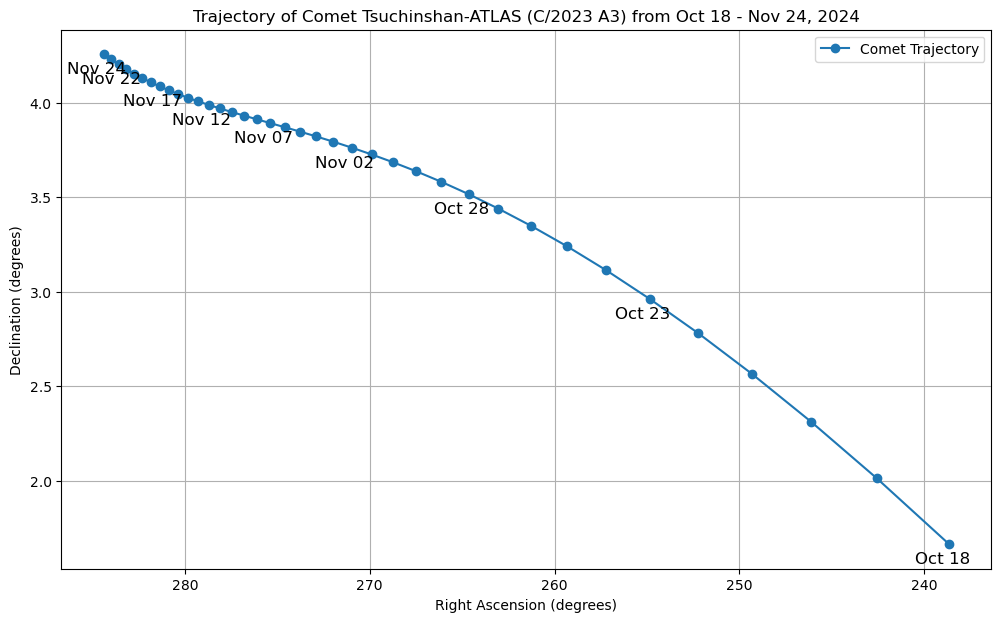

In [57]:

# Load the file
file_path = "horizons_results.txt"
with open(file_path, "r") as file:
    lines = file.readlines()

# Extract the data section
data_start = lines.index("$$SOE\n") + 1
data_end = lines.index("$$EOE\n")
data_lines = lines[data_start:data_end]


# Extract RA and Dec values while ensuring proper format
data = []
for line in data_lines:
    columns = line.split()
    if len(columns) >= 8:  # Ensure sufficient columns exist
        try:
            date_part = f"{columns[0]} {columns[1]}"  # Date in "YYYY-MMM-DD HH:MM" format
            ra_part = " ".join(columns[2:5])  # RA in "HH MM SS.SS"
            dec_part = " ".join(columns[5:8])  # Dec in "±DD MM SS.SS"

            # Ensure RA has three parts
            ra_parts = ra_part.split()
            if len(ra_parts) == 2:
                ra_part = f"{ra_parts[0]} {ra_parts[1]} {ra_parts[2]}"
            
            # Ensure Dec has three parts
            dec_parts = dec_part.split()
            if len(dec_parts) == 2:
                dec_part = f"{dec_parts[0]} {dec_parts[1]} {dec_parts[2]}"
            
            data.append([date_part, ra_part, dec_part])
        except ValueError:
            continue  # Skip lines with unexpected formatting

# Create a DataFrame
df = pd.DataFrame(data, columns=["Date", "RA", "Dec"])

# Function to convert RA from HMS to Decimal Degrees
def hms_to_degrees(hms):
    h, m, s = map(float, hms.split())
    return 15 * (h + m / 60 + s / 3600)  # 1 hour = 15 degrees

# Function to convert Dec from DMS to Decimal Degrees
def dms_to_degrees(dms):
    d, m, s = map(float, dms.split())
    sign = -1 if d < 0 else 1
    return sign * (abs(d) + m / 60 + s / 3600)

# Convert RA and Dec to Decimal Degrees
df["RA (deg)"] = df["RA"].apply(hms_to_degrees)
df["Dec (deg)"] = df["Dec"].apply(dms_to_degrees)

# Convert Date to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Filter for the correct date range
df_filtered = df[(df["Date"] >= "2024-10-18") & (df["Date"] <= "2024-11-24")]

# Select every 5th date plus the first and last dates
filtered_dates = list(range(0, len(df_filtered), 5))  # Every 5th index
if len(df_filtered) - 1 not in filtered_dates:  # Ensure last date is included
    filtered_dates.append(len(df_filtered) - 1)

# Plot the corrected trajectory
plt.figure(figsize=(12, 7))
plt.plot(df_filtered["RA (deg)"], df_filtered["Dec (deg)"], marker="o", linestyle="-", label="Comet Trajectory")

# Annotate only every 5th date and the first/last dates
for i in filtered_dates:
    plt.annotate(df_filtered["Date"].iloc[i].strftime("%b %d"), 
                 (df_filtered["RA (deg)"].iloc[i], df_filtered["Dec (deg)"].iloc[i]), 
                 textcoords="offset points", xytext=(-5,-14), ha='center', fontsize=12)

# Labels and formatting
plt.xlabel("Right Ascension (degrees)")
plt.ylabel("Declination (degrees)")
plt.title("Trajectory of Comet Tsuchinshan-ATLAS (C/2023 A3) from Oct 18 - Nov 24, 2024")
plt.gca().invert_xaxis()  # Right Ascension increases to the left
plt.grid(True)
plt.legend()

# Show the plot
plt.show()


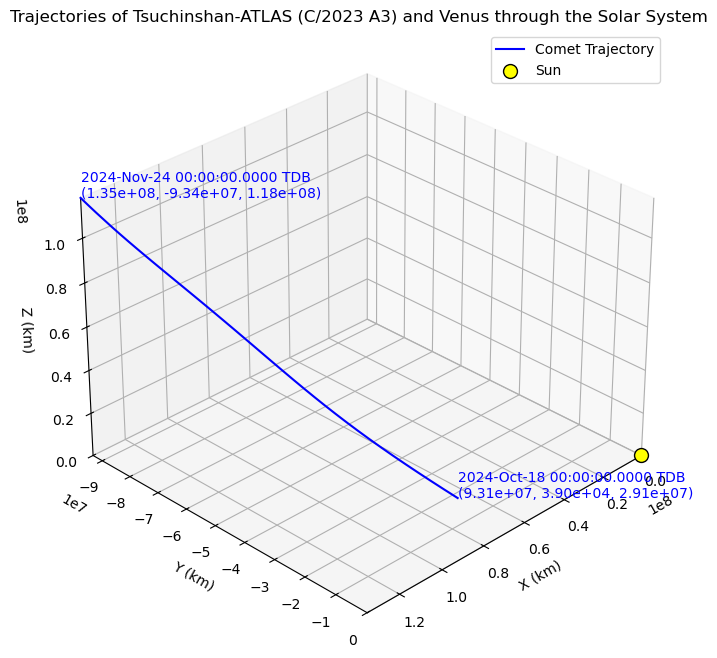

In [9]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Function to extract trajectory data from Horizons output
def extract_trajectory(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    start_idx = lines.index("$$SOE\n") + 1  # Start of data
    end_idx = lines.index("$$EOE\n")        # End of data
    
    data = []
    for i in range(start_idx, end_idx):
        line = lines[i].strip()
        
        # Ensure the line contains valid data (skip headers)
        if re.match(r"\d{4}-[A-Za-z]{3}-\d{2}", line):  # Match YYYY-MMM-DD format
            date = line  # Date is the first entry

            # Extract position values from the next line
            if i + 1 < end_idx:
                pos_line = lines[i + 1]
                pos_values = re.findall(r"[-+]?\d*\.\d+E[+-]?\d+", pos_line)

                if len(pos_values) >= 3:
                    x, y, z = map(float, pos_values[:3])  # Extract X, Y, Z
                    data.append((date, x, y, z))

    if not data:
        raise ValueError(f"No valid trajectory data found in {file_path}")

    return zip(*data)  # Unzip into separate lists

# Load comet trajectory
dates, comet_X_vals, comet_Y_vals, comet_Z_vals = extract_trajectory("horizons_results_trajectory.txt")


# Convert lists to numpy arrays for plotting
comet_X_vals = np.array(comet_X_vals)
comet_Y_vals = np.array(comet_Y_vals)
comet_Z_vals = np.array(comet_Z_vals)



# Generate a corrected 3D plot ensuring Y-axis motion is visible
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the comet's trajectory
ax.plot(comet_X_vals, comet_Y_vals, comet_Z_vals, label="Comet Trajectory", color='blue')


# Mark the Sun at the origin (0,0,0)
ax.scatter(0, 0, 0, color='yellow', s=100, edgecolors='black', label="Sun", zorder=10)

# Labels and aesthetics
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.set_title("Trajectories of Tsuchinshan-ATLAS (C/2023 A3) and Venus through the Solar System")
ax.legend()

# Annotate the first and last points of the comet's trajectory
ax.text(comet_X_vals[0], comet_Y_vals[0], comet_Z_vals[0], 
        f"{dates[0]}\n({comet_X_vals[0]:.2e}, {comet_Y_vals[0]:.2e}, {comet_Z_vals[0]:.2e})", 
        color='blue', fontsize=10)
ax.text(comet_X_vals[-1], comet_Y_vals[-1], comet_Z_vals[-1], 
        f"{dates[-1]}\n({comet_X_vals[-1]:.2e}, {comet_Y_vals[-1]:.2e}, {comet_Z_vals[-1]:.2e})", 
        color='blue', fontsize=10)



# Adjust the view angle to emphasize Y-axis motion
ax.view_init(elev=30, azim=45)  # Adjust elevation and azimuth angles

# Set axis limits ensuring Sun is centered and Y-axis is visible
x_min, x_max = min(comet_X_vals), max(comet_X_vals)
y_min, y_max = min(comet_Y_vals), max(comet_Y_vals)
z_min, z_max = min(comet_Z_vals), max(comet_Z_vals)

ax.set_xlim([min(0, x_min), max(0, x_max)])
ax.set_ylim([min(0, y_min), max(0, y_max)])
ax.set_zlim([min(0, z_min), max(0, z_max)])

# Display the plot
plt.show()


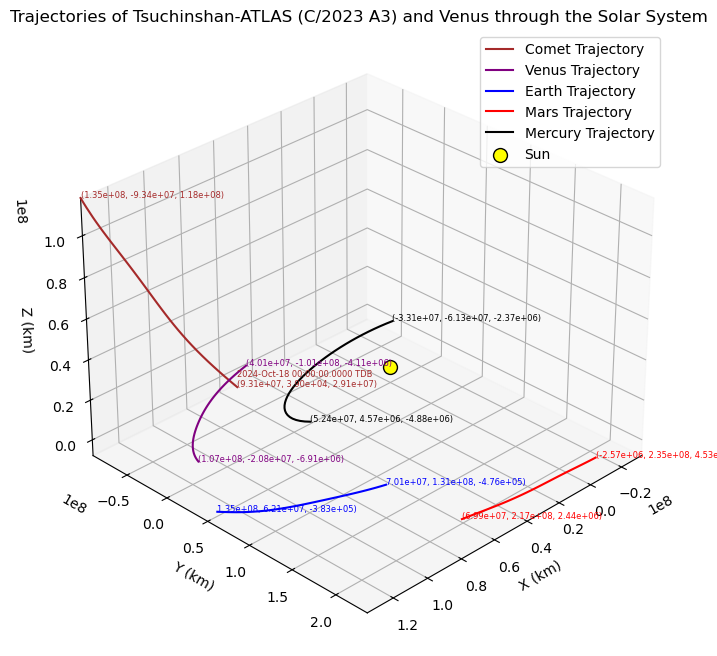

In [10]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Function to extract trajectory data from Horizons output
def extract_trajectory(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    start_idx = lines.index("$$SOE\n") + 1  # Start of data
    end_idx = lines.index("$$EOE\n")        # End of data
    
    data = []
    for i in range(start_idx, end_idx):
        line = lines[i].strip()
        
        # Ensure the line contains valid data (skip headers)
        if re.match(r"\d{4}-[A-Za-z]{3}-\d{2}", line):  # Match YYYY-MMM-DD format
            date = line  # Date is the first entry

            # Extract position values from the next line
            if i + 1 < end_idx:
                pos_line = lines[i + 1]
                pos_values = re.findall(r"[-+]?\d*\.\d+E[+-]?\d+", pos_line)

                if len(pos_values) >= 3:
                    x, y, z = map(float, pos_values[:3])  # Extract X, Y, Z
                    data.append((date, x, y, z))

    if not data:
        raise ValueError(f"No valid trajectory data found in {file_path}")

    return zip(*data)  # Unzip into separate lists

# Load comet trajectory
dates, comet_X_vals, comet_Y_vals, comet_Z_vals = extract_trajectory("horizons_results_trajectory.txt")

# Load Venus trajectory
venus_dates, venus_X_vals, venus_Y_vals, venus_Z_vals = extract_trajectory("horizons_results_venus.txt")

earth_dates, earth_X_vals, earth_Y_vals, earth_Z_vals = extract_trajectory("horizons_results_earth.txt")

mercury_dates, mercury_X_vals, mercury_Y_vals, mercury_Z_vals = extract_trajectory("horizons_results_mercury.txt")

mars_dates, mars_X_vals, mars_Y_vals, mars_Z_vals = extract_trajectory("horizons_results_mars.txt")

# Convert lists to numpy arrays for plotting
comet_X_vals = np.array(comet_X_vals)
comet_Y_vals = np.array(comet_Y_vals)
comet_Z_vals = np.array(comet_Z_vals)

venus_X_vals = np.array(venus_X_vals)
venus_Y_vals = np.array(venus_Y_vals)
venus_Z_vals = np.array(venus_Z_vals)

earth_X_vals = np.array(earth_X_vals)
earth_Y_vals = np.array(earth_Y_vals)
earth_Z_vals = np.array(earth_Z_vals)

mercury_X_vals = np.array(mercury_X_vals)
mercury_Y_vals = np.array(mercury_Y_vals)
mercury_Z_vals = np.array(mercury_Z_vals)

mars_X_vals = np.array(mars_X_vals)
mars_Y_vals = np.array(mars_Y_vals)
mars_Z_vals = np.array(mars_Z_vals)

# Generate a corrected 3D plot ensuring Y-axis motion is visible
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the comet's trajectory
ax.plot(comet_X_vals, comet_Y_vals, comet_Z_vals, label="Comet Trajectory", color='brown')

# Plot Venus' trajectory
ax.plot(venus_X_vals, venus_Y_vals, venus_Z_vals, label="Venus Trajectory", color='purple')

ax.plot(earth_X_vals, earth_Y_vals, earth_Z_vals, label="Earth Trajectory", color='blue')

ax.plot(mars_X_vals, mars_Y_vals, mars_Z_vals, label="Mars Trajectory", color='red')

ax.plot(mercury_X_vals, mercury_Y_vals, mercury_Z_vals, label="Mercury Trajectory", color='black')

# Mark the Sun at the origin (0,0,0)
ax.scatter(0, 0, 0, color='yellow', s=100, edgecolors='black', label="Sun", zorder=10)

# Labels and aesthetics
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.set_title("Trajectories of Tsuchinshan-ATLAS (C/2023 A3) and Venus through the Solar System")
ax.legend()

# Annotate the first and last points of the comet's trajectory
ax.text(comet_X_vals[0], comet_Y_vals[0], comet_Z_vals[0], 
        f"{dates[0]}\n({comet_X_vals[0]:.2e}, {comet_Y_vals[0]:.2e}, {comet_Z_vals[0]:.2e})", 
        color='brown', fontsize=6)
ax.text(comet_X_vals[-1], comet_Y_vals[-1], comet_Z_vals[-1], 
        f"({comet_X_vals[-1]:.2e}, {comet_Y_vals[-1]:.2e}, {comet_Z_vals[-1]:.2e})", 
        color='brown', fontsize=6)

ax.text(earth_X_vals[0], earth_Y_vals[0], earth_Z_vals[0], 
        f"{earth_X_vals[0]:.2e}, {earth_Y_vals[0]:.2e}, {earth_Z_vals[0]:.2e})", 
        color='blue', fontsize=6)
ax.text(earth_X_vals[-1], earth_Y_vals[-1], earth_Z_vals[-1], 
        f"{earth_X_vals[-1]:.2e}, {earth_Y_vals[-1]:.2e}, {earth_Z_vals[-1]:.2e})", 
        color='blue', fontsize=6)

ax.text(mercury_X_vals[0], mercury_Y_vals[0], mercury_Z_vals[0], 
        f"({mercury_X_vals[0]:.2e}, {mercury_Y_vals[0]:.2e}, {mercury_Z_vals[0]:.2e})", 
        color='black', fontsize=6)
ax.text(mercury_X_vals[-1], mercury_Y_vals[-1], mercury_Z_vals[-1], 
        f"({mercury_X_vals[-1]:.2e}, {mercury_Y_vals[-1]:.2e}, {mercury_Z_vals[-1]:.2e})", 
        color='black', fontsize=6)

ax.text(mars_X_vals[0], mars_Y_vals[0], mars_Z_vals[0], 
        f"({mars_X_vals[0]:.2e}, {mars_Y_vals[0]:.2e}, {mars_Z_vals[0]:.2e})", 
        color='red', fontsize=6)
ax.text(mars_X_vals[-1], mars_Y_vals[-1], mars_Z_vals[-1], 
        f"({mars_X_vals[-1]:.2e}, {mars_Y_vals[-1]:.2e}, {mars_Z_vals[-1]:.2e})", 
        color='red', fontsize=6)

# Annotate the first and last points of Venus' trajectory
ax.text(venus_X_vals[0], venus_Y_vals[0], venus_Z_vals[0], 
        f"({venus_X_vals[0]:.2e}, {venus_Y_vals[0]:.2e}, {venus_Z_vals[0]:.2e})", 
        color='purple', fontsize=6)
ax.text(venus_X_vals[-1], venus_Y_vals[-1], venus_Z_vals[-1], 
        f"({venus_X_vals[-1]:.2e}, {venus_Y_vals[-1]:.2e}, {venus_Z_vals[-1]:.2e})", 
        color='purple', fontsize=6)

# Adjust the view angle to emphasize Y-axis motion
ax.view_init(elev=30, azim=45)  # Adjust elevation and azimuth angles

# Set axis limits ensuring Sun is centered and Y-axis is visible
x_min, x_max = min(min(comet_X_vals), min(mercury_X_vals)), max(max(comet_X_vals), max(mars_X_vals))
y_min, y_max = min(min(comet_Y_vals), min(mercury_Y_vals)), max(max(comet_Y_vals), max(mars_Y_vals))
z_min, z_max = min(min(comet_Z_vals), min(mercury_Z_vals)), max(max(comet_Z_vals), max(mars_Z_vals))

ax.set_xlim([min(0, x_min), max(0, x_max)])
ax.set_ylim([min(0, y_min), max(0, y_max)])
ax.set_zlim([min(0, z_min), max(0, z_max)])

# Display the plot
plt.show()


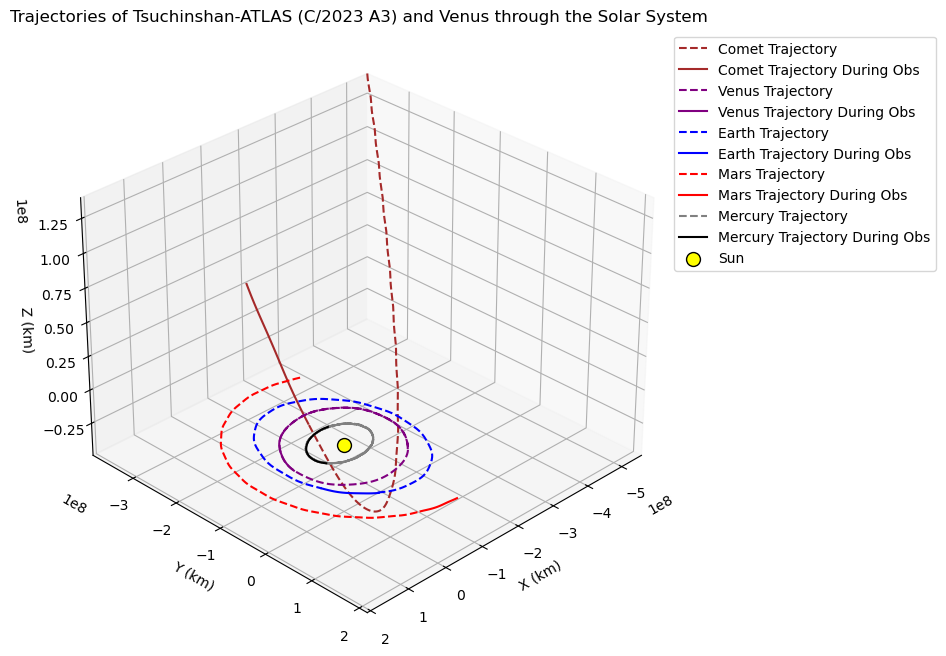

In [105]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Function to extract trajectory data from Horizons output
def extract_trajectory(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    start_idx = lines.index("$$SOE\n") + 1  # Start of data
    end_idx = lines.index("$$EOE\n")        # End of data
    
    data = []
    for i in range(start_idx, end_idx):
        line = lines[i].strip()
        
        # Ensure the line contains valid data (skip headers)
        if re.match(r"\d{4}-[A-Za-z]{3}-\d{2}", line):  # Match YYYY-MMM-DD format
            date = line  # Date is the first entry

            # Extract position values from the next line
            if i + 1 < end_idx:
                pos_line = lines[i + 1]
                pos_values = re.findall(r"[-+]?\d*\.\d+E[+-]?\d+", pos_line)

                if len(pos_values) >= 3:
                    x, y, z = map(float, pos_values[:3])  # Extract X, Y, Z
                    data.append((date, x, y, z))

    if not data:
        raise ValueError(f"No valid trajectory data found in {file_path}")

    return zip(*data)  # Unzip into separate lists

# Load comet trajectory
dates, comet_X_vals, comet_Y_vals, comet_Z_vals = extract_trajectory("horizons_results_trajectory.txt")

dates_year, comet_X_vals_year, comet_Y_vals_year, comet_Z_vals_year = extract_trajectory("horizons_results_C2023_year.txt")

# Load Venus trajectory
venus_dates, venus_X_vals, venus_Y_vals, venus_Z_vals = extract_trajectory("horizons_results_venus.txt")

venus_dates_year, venus_X_vals_year, venus_Y_vals_year, venus_Z_vals_year = extract_trajectory("horizons_results_venus_year.txt")

earth_dates, earth_X_vals, earth_Y_vals, earth_Z_vals = extract_trajectory("horizons_results_earth.txt")

earth_dates_year, earth_X_vals_year, earth_Y_vals_year, earth_Z_vals_year = extract_trajectory("horizons_results_earth_year.txt")

mercury_dates, mercury_X_vals, mercury_Y_vals, mercury_Z_vals = extract_trajectory("horizons_results_mercury.txt")

mercury_dates_year, mercury_X_vals_year, mercury_Y_vals_year, mercury_Z_vals_year = extract_trajectory("horizons_results_mercury_year.txt")

mars_dates, mars_X_vals, mars_Y_vals, mars_Z_vals = extract_trajectory("horizons_results_mars.txt")

mars_dates_year, mars_X_vals_year, mars_Y_vals_year, mars_Z_vals_year = extract_trajectory("horizons_results_mars_year.txt")

# Convert lists to numpy arrays for plotting
comet_X_vals = np.array(comet_X_vals)
comet_Y_vals = np.array(comet_Y_vals)
comet_Z_vals = np.array(comet_Z_vals)

# Convert lists to numpy arrays for plotting
comet_X_vals_year = np.array(comet_X_vals_year)
comet_Y_vals_year = np.array(comet_Y_vals_year)
comet_Z_vals_year = np.array(comet_Z_vals_year)

venus_X_vals = np.array(venus_X_vals)
venus_Y_vals = np.array(venus_Y_vals)
venus_Z_vals = np.array(venus_Z_vals)

venus_X_vals_year = np.array(venus_X_vals_year)
venus_Y_vals_year = np.array(venus_Y_vals_year)
venus_Z_vals_year = np.array(venus_Z_vals_year)

earth_X_vals = np.array(earth_X_vals)
earth_Y_vals = np.array(earth_Y_vals)
earth_Z_vals = np.array(earth_Z_vals)

earth_X_vals_year = np.array(earth_X_vals_year)
earth_Y_vals_year = np.array(earth_Y_vals_year)
earth_Z_vals_year = np.array(earth_Z_vals_year)

mercury_X_vals = np.array(mercury_X_vals)
mercury_Y_vals = np.array(mercury_Y_vals)
mercury_Z_vals = np.array(mercury_Z_vals)

mercury_X_vals_year = np.array(mercury_X_vals_year)
mercury_Y_vals_year = np.array(mercury_Y_vals_year)
mercury_Z_vals_year = np.array(mercury_Z_vals_year)

mars_X_vals = np.array(mars_X_vals)
mars_Y_vals = np.array(mars_Y_vals)
mars_Z_vals = np.array(mars_Z_vals)

mars_X_vals_year = np.array(mars_X_vals_year)
mars_Y_vals_year = np.array(mars_Y_vals_year)
mars_Z_vals_year = np.array(mars_Z_vals_year)

# Generate a corrected 3D plot ensuring Y-axis motion is visible
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the comet's trajectory
ax.plot(comet_X_vals_year, comet_Y_vals_year, comet_Z_vals_year, label="Comet Trajectory", color='brown', linestyle='--')

# Plot the comet's trajectory
ax.plot(comet_X_vals, comet_Y_vals, comet_Z_vals, label="Comet Trajectory During Obs", color='brown')

ax.plot(venus_X_vals_year, venus_Y_vals_year, venus_Z_vals_year, label="Venus Trajectory", color='purple', linestyle='--')

# Plot Venus' trajectory
ax.plot(venus_X_vals, venus_Y_vals, venus_Z_vals, label="Venus Trajectory During Obs", color='purple')

ax.plot(earth_X_vals_year, earth_Y_vals_year, earth_Z_vals_year, label="Earth Trajectory", color='blue', linestyle='--')

ax.plot(earth_X_vals, earth_Y_vals, earth_Z_vals, label="Earth Trajectory During Obs", color='blue')

ax.plot(mars_X_vals_year, mars_Y_vals_year, mars_Z_vals_year, label="Mars Trajectory", color='red', linestyle='--')

ax.plot(mars_X_vals, mars_Y_vals, mars_Z_vals, label="Mars Trajectory During Obs", color='red')

ax.plot(mercury_X_vals_year, mercury_Y_vals_year, mercury_Z_vals_year, label="Mercury Trajectory", color='grey', linestyle='--')

ax.plot(mercury_X_vals, mercury_Y_vals, mercury_Z_vals, label="Mercury Trajectory During Obs", color='black')

# Mark the Sun at the origin (0,0,0)
ax.scatter(0, 0, 0, color='yellow', s=100, edgecolors='black', label="Sun", zorder=10)

# Labels and aesthetics
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.set_title("Trajectories of Tsuchinshan-ATLAS (C/2023 A3) and Venus through the Solar System")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))



# Adjust the view angle to emphasize Y-axis motion
ax.view_init(elev=30, azim=45)  # Adjust elevation and azimuth angles

# Set axis limits ensuring Sun is centered and Y-axis is visible
x_min, x_max = min(min(comet_X_vals_year), min(mars_X_vals_year)), max(max(comet_X_vals_year), max(mars_X_vals_year))
y_min, y_max = min(min(comet_Y_vals_year), min(mars_Y_vals_year)), max(max(comet_Y_vals_year), max(mars_Y_vals_year))
z_min, z_max = min(min(comet_Z_vals_year), min(mars_Z_vals_year)), max(max(comet_Z_vals_year), max(mars_Z_vals_year))

ax.set_xlim([min(0, x_min), max(0, x_max)])
ax.set_ylim([min(0, y_min), max(0, y_max)])
ax.set_zlim([min(0, z_min), max(0, z_max)])

# Display the plot
plt.show()


In [12]:
ax.scatter(comet_X_vals[0], comet_Y_vals[0], comet_Z_vals[0], color='brown', label="Comet Start", s=40)
ax.scatter(comet_X_vals[-1], comet_Y_vals[-1], comet_Z_vals[-1], color='brown', label="Comet End", s=40)
ax.scatter(venus_X_vals[0], venus_Y_vals[0], venus_Z_vals[0], color='purple', label="Venus Start", s=40)
ax.scatter(venus_X_vals[-1], venus_Y_vals[-1], venus_Z_vals[-1], color='purple', label="Venus End", s=40)
ax.scatter(earth_X_vals[0], earth_Y_vals[0], earth_Z_vals[0], color='blue', label="Earth Start", s=40)
ax.scatter(earth_X_vals[-1], earth_Y_vals[-1], earth_Z_vals[-1], color='blue', label="Earth End", s=40)
ax.scatter(mars_X_vals[0], mars_Y_vals[0], mars_Z_vals[0], color='red', label="Mars Start", s=40)
ax.scatter(mars_X_vals[-1], mars_Y_vals[-1], mars_Z_vals[-1], color='red', label="Mars End", s=40)
ax.scatter(mercury_X_vals[0], mercury_Y_vals[0], mercury_Z_vals[0], color='black', label="Mercury Start", s=40)
ax.scatter(mercury_X_vals[-1], mercury_Y_vals[-1], mercury_Z_vals[-1], color='black', label="Mercury End", s=40)

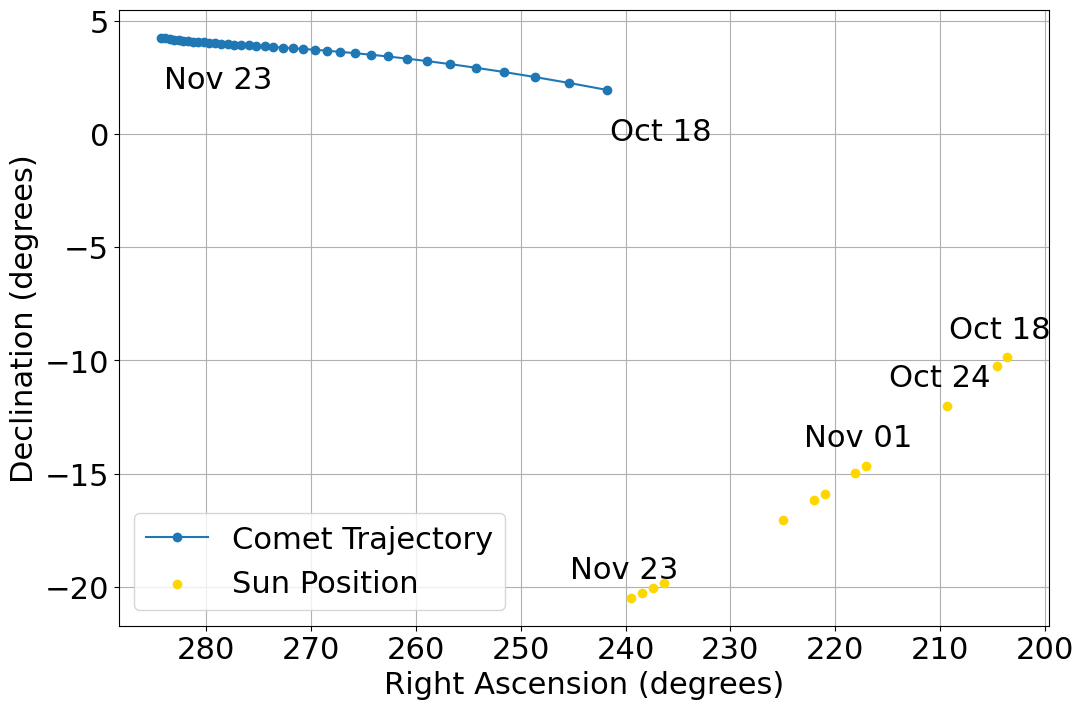

Angular separation on 2024-10-19: 42.508 degrees


In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u

# =========================
# 1. Load and process COMET data
# =========================
file_path = "horizons_results_19_00.txt"  # Adjust if your file is named differently

with open(file_path, "r") as file:
    lines = file.readlines()

# Extract data section
data_start = lines.index("$$SOE\n") + 1
data_end = lines.index("$$EOE\n")
data_lines = lines[data_start:data_end]

# Parse comet data
comet_data = []
for line in data_lines:
    columns = line.split()
    if len(columns) >= 8:
        date_part = f"{columns[0]} {columns[1]}"
        ra_part = " ".join(columns[2:5])
        dec_part = " ".join(columns[5:8])
        comet_data.append([date_part, ra_part, dec_part])

df_comet = pd.DataFrame(comet_data, columns=["Date", "RA", "Dec"])

# Conversion functions
def hms_to_degrees(hms):
    h, m, s = map(float, hms.split())
    return 15 * (h + m / 60 + s / 3600)

def dms_to_degrees(dms):
    d, m, s = map(float, dms.split())
    sign = -1 if d < 0 else 1
    return sign * (abs(d) + m / 60 + s / 3600)

df_comet["RA (deg)"] = df_comet["RA"].apply(hms_to_degrees)
df_comet["Dec (deg)"] = df_comet["Dec"].apply(dms_to_degrees)
df_comet["Date"] = pd.to_datetime(df_comet["Date"])

# Filter for target dates
df_comet_filtered = df_comet[(df_comet["Date"] >= "2024-10-18") & (df_comet["Date"] <= "2024-11-24")]

comet_label_indices = [0, len(df_comet_filtered) - 1]


# =========================
# 2. Load and process SUN data
# =========================
sun_files = [
    "horizons_results_Sun_RA_DEC_011124.txt",
    "horizons_results_SUN_RA_DEC_021124.txt",
    "horizons_results_Sun_RA_DEC_051124.txt",
    "horizons_results_Sun_RA_DEC_061124.txt",
    "horizons_results_Sun_RA_DEC_091124.txt",
    "horizons_results_Sun_RA_DEC_181024.txt",
    "horizons_results_Sun_RA_DEC_191024.txt",
    "horizons_results_Sun_RA_DEC_201124.txt",
    "horizons_results_Sun_RA_DEC_211124.txt",
    "horizons_results_Sun_RA_DEC_221124.txt",
    "horizons_results_Sun_RA_DEC_231124.txt",
    "horizons_results_Sun_RA_DEC_241024.txt"
]

def parse_sun_file(file_path):
    sun_data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()

    data_start = lines.index("$$SOE\n") + 1
    data_end = lines.index("$$EOE\n")

    for line in lines[data_start:data_end]:
        columns = line.split()

        # Detect and remove "A", "m" flags if present after the date
        if columns[2] in ["A", "m", "Am"]:
            columns.pop(2)

        date_time = f"{columns[0]} {columns[1]}"
        ra = " ".join(columns[2:5])
        dec = " ".join(columns[5:8])

        try:
            ra_deg = hms_to_degrees(ra)
            dec_deg = dms_to_degrees(dec)
            sun_data.append([date_time, ra_deg, dec_deg])
        except (ValueError, IndexError) as e:
            print(f"Skipping malformed line in {file_path}: {line.strip()} - {e}")

    sun_df = pd.DataFrame(sun_data, columns=["Date", "RA (deg)", "Dec (deg)"])
    sun_df["Date"] = pd.to_datetime(sun_df["Date"])
    return sun_df

# Read all sun files
df_sun = pd.concat([parse_sun_file(f) for f in sun_files], ignore_index=True)

# Filter Sun data for date range
df_sun_filtered = df_sun[(df_sun["Date"] >= "2024-10-18") & (df_sun["Date"] <= "2024-11-24")]

# Keep only the first entry per day
df_sun_filtered["DateOnly"] = df_sun_filtered["Date"].dt.date
df_sun_filtered = df_sun_filtered.drop_duplicates(subset=["DateOnly"], keep="first").drop(columns=["DateOnly"])


# First, every 5th, and last date indices for Sun (same as comet logic)
sun_label_indices = list(range(0, len(df_sun_filtered), 5))
if len(df_sun_filtered) - 1 not in sun_label_indices:
    sun_label_indices.append(len(df_sun_filtered) - 1)


# =========================
# 3. Plotting
# =========================
plt.figure(figsize=(12, 8))

# Plot comet trajectory
plt.plot(df_comet_filtered["RA (deg)"], df_comet_filtered["Dec (deg)"],
         marker="o", linestyle="-", label="Comet Trajectory", zorder=2)

for idx, i in enumerate(comet_label_indices):
    date_str = df_comet_filtered["Date"].iloc[i].strftime("%b %d")
    ra = df_comet_filtered["RA (deg)"].iloc[i]
    dec = df_comet_filtered["Dec (deg)"].iloc[i]
    
    # Alternate offset direction to reduce overlap
    plt.annotate(date_str, (ra, dec),
             textcoords="offset points", xytext=(2, -20), ha='left', va='top', fontsize=22)

# Plot Sun positions
plt.scatter(df_sun_filtered["RA (deg)"], df_sun_filtered["Dec (deg)"],
            color="gold", label="Sun Position", zorder=3)

# Annotate Sun positions (first, every 5th, and last date - same logic as comet)
for i in sun_label_indices:
    date_str = df_sun_filtered["Date"].iloc[i].strftime("%b %d")
    ra = df_sun_filtered["RA (deg)"].iloc[i]
    dec = df_sun_filtered["Dec (deg)"].iloc[i]
    plt.annotate(date_str, (ra, dec), textcoords="offset points", xytext=(-5, 14), ha='center', fontsize=22, color="black")

plt.xlabel("Right Ascension (degrees)", fontsize = 22)
plt.ylabel("Declination (degrees)", fontsize = 22)
plt.tick_params(axis='both', labelsize=22)
#plt.title("Comet Tsuchinshan-ATLAS (C/2023 A3) and Sun Position\nOct 18 - Nov 24, 2024")
plt.gca().invert_xaxis()  # Right Ascension increases to the left
plt.grid(True)
plt.legend(fontsize = 22)
plt.savefig("/Users/kylerichardaffleck/Downloads/comet_sun_position.pdf", dpi=600)
# Plot formatting
plt.show()
# Extract comet and sun positions for Nov 1, 2024
date_of_interest = pd.to_datetime("2024-10-19")

# Get closest entries for that date
comet_row = df_comet_filtered[df_comet_filtered["Date"].dt.date == date_of_interest.date()]
sun_row = df_sun_filtered[df_sun_filtered["Date"].dt.date == date_of_interest.date()]

if not comet_row.empty and not sun_row.empty:
    comet_coord = SkyCoord(ra=comet_row["RA (deg)"].values[0]*u.deg,
                           dec=comet_row["Dec (deg)"].values[0]*u.deg, frame='icrs')
    sun_coord = SkyCoord(ra=sun_row["RA (deg)"].values[0]*u.deg,
                         dec=sun_row["Dec (deg)"].values[0]*u.deg, frame='icrs')

    # Calculate angular separation
    angular_sep = comet_coord.separation(sun_coord)
    print(f"Angular separation on {date_of_interest.date()}: {angular_sep.deg:.3f} degrees")
else:
    print("Comet or Sun data not found for 2024-11-01.")

In [37]:

# Load the file
file_path = "horizons_results_19_00.txt"
with open(file_path, "r") as file:
    lines = file.readlines()

# Extract the data section
data_start = lines.index("$$SOE\n") + 1
data_end = lines.index("$$EOE\n")
data_lines = lines[data_start:data_end]


# Extract RA and Dec values while ensuring proper format
data = []
for line in data_lines:
    columns = line.split()
    if len(columns) >= 8:  # Ensure sufficient columns exist
        try:
            date_part = f"{columns[0]} {columns[1]}" 
            delta_part = " ".join(columns[10])
            
            
            data.append([date_part, delta_part])
        except ValueError:
            continue  # Skip lines with unexpected formatting

# Create a DataFrame
df = pd.DataFrame(data, columns=["Date","Delta (AU)"])
df
# Define the output file path in the Jupyter home directory
output_file_path = "horizons_delta_au.txt"

# Save the DataFrame as a tab-separated text file
df.to_csv(output_file_path, sep='\t', index=False)

print(f"File saved at: {output_file_path}")

File saved at: horizons_delta_au.txt


In [35]:
import re
import pandas as pd
import numpy as np

# Define the file path
file_path = "horizons_results_trajectory_19_00.txt"

# Read the file
with open(file_path, 'r') as file:
    lines = file.readlines()

# Identify the start and end of the data section
start_idx = lines.index("$$SOE\n") + 1  # Start of data
end_idx = lines.index("$$EOE\n")        # End of data

# Initialize lists to store data
dates = []
comet_X_vals = []
comet_Y_vals = []
comet_Z_vals = []
distances_AU = []

# Conversion factor: 1 AU = 149597870.7 km
KM_TO_AU = 1.0 / 149597870.7

# Iterate through lines and extract the correct date and position data
for i in range(start_idx, end_idx, 4):  # Each entry spans 4 lines
    date_line = lines[i].strip()
    pos_line = lines[i + 1].strip()

    # Extract only the date portion (first part of the line before time and TDB)
    date_match = re.match(r"(\d{4}-[A-Za-z]{3}-\d{2})", date_line)
    if date_match:
        date = date_match.group(1)
    else:
        print(f"Skipping line due to missing date: {date_line}")
        continue  # Skip if no valid date found

    # Extract X, Y, Z values
    pos_values = re.findall(r"[-+]?\d*\.\d+E[+-]?\d+", pos_line)
    if len(pos_values) >= 3:
        x, y, z = map(float, pos_values[:3])  # Extract X, Y, Z
        distance_km = np.sqrt(x**2 + y**2 + z**2)  # Compute distance to Sun in km
        distance_AU = distance_km * KM_TO_AU  # Convert to AU

        # Store values
        dates.append(date)
        comet_X_vals.append(x)
        comet_Y_vals.append(y)
        comet_Z_vals.append(z)
        distances_AU.append(distance_AU)
    else:
        print(f"Skipping line due to missing position data: {pos_line}")

# Create and display the DataFrame
df_corrected = pd.DataFrame({
    "Date": dates,
    "X (km)": comet_X_vals,
    "Y (km)": comet_Y_vals,
    "Z (km)": comet_Z_vals,
    "Distance to Sun (AU)": distances_AU
})

# Print the DataFrame to display results
df_corrected

# Define the output file path in the Jupyter home directory
output_file_path = "horizons_r_h.txt"

# Save the DataFrame as a tab-separated text file
df_corrected.to_csv(output_file_path, sep='\t', index=False)

print(f"File saved at: {output_file_path}")

File saved at: horizons_r_h.txt


In [11]:
import numpy as np
import pandas as pd

# Function to extract timestamp, position, and velocity data correctly
def extract_positions_and_velocities(filename):
    positions = []
    velocities = []
    timestamps = []
    data_section = False

    with open(filename, "r") as file:
        lines = file.readlines()

    for i in range(len(lines) - 2):  # Iterate through the file while looking ahead for position & velocity data
        line = lines[i].strip()

        if "$$SOE" in line:
            data_section = True
            continue
        if "$$EOE" in line:
            break

        if data_section:
            parts = line.split()
            if len(parts) >= 2 and parts[1] == "=":  # Detect Julian Date line
                try:
                    current_timestamp = float(parts[0])  # Store Julian Date
                    next_line = lines[i + 1].strip()  # Position data line
                    velocity_line = lines[i + 2].strip()  # Velocity data line

                    if "X =" in next_line and "Y =" in next_line and "Z =" in next_line:
                        pos_parts = next_line.replace("X =", "").replace("Y =", "").replace("Z =", "").split()
                        vel_parts = velocity_line.replace("VX=", "").replace("VY=", "").replace("VZ=", "").split()
                        
                        positions.append([float(pos_parts[0]), float(pos_parts[1]), float(pos_parts[2])])
                        velocities.append([float(vel_parts[0]), float(vel_parts[1]), float(vel_parts[2])])
                        timestamps.append(current_timestamp)  # Associate position with timestamp

                except ValueError:
                    continue

    return np.array(timestamps), np.array(positions), np.array(velocities)

# File paths from uploaded data
earth_comet_file = "horizons_results_vector_table_earth_comet.txt"
sun_comet_file = "horizons_results_vector_table_sun_comet.txt"

# Extracting position and velocity data from files
timestamps_earth_comet, r_ec_data, v_ec_data = extract_positions_and_velocities(earth_comet_file)
timestamps_sun_comet, r_sc_data, v_sc_data = extract_positions_and_velocities(sun_comet_file)

# Ensure both datasets align in time (taking minimum available length)
min_length = min(len(r_ec_data), len(r_sc_data))
timestamps = timestamps_earth_comet[:min_length]  # Use timestamps from Earth-Comet data

# Earth's normal vector in the ecliptic plane (Z-axis points out of the plane)
N_earth = np.array([0, 0, 1])

# Compute phase angles and plane angles for each time step
phase_angles = []
plane_angles = []

for i in range(min_length):
    r_sc = r_sc_data[i]  # Sun-to-Comet vector
    v_sc = v_sc_data[i]  # Sun-to-Comet velocity

    # Compute the normal to the comet's orbital plane (h = r × v)
    h_comet = np.cross(r_sc, v_sc)
    N_comet = h_comet / np.linalg.norm(h_comet)  # Normalize

    # Compute the plane angle using dot product with Earth's normal vector
    plane_angle = np.arccos(np.dot(N_earth, N_comet)) * (180 / np.pi)

    # Compute phase angle (Sun-Comet-Earth)
    r_ec = r_ec_data[i]  # Earth-to-Comet vector
    mag_r_sc = np.linalg.norm(r_sc)
    mag_r_ec = np.linalg.norm(r_ec)
    dot_product = np.dot(r_sc, r_ec)
    phase_angle = np.arccos(dot_product / (mag_r_sc * mag_r_ec)) * (180 / np.pi)

    # Append values
    phase_angles.append(phase_angle)
    plane_angles.append(plane_angle)

# Create a DataFrame to display results
results_df = pd.DataFrame({
    "Julian Date": timestamps,
    "Phase Angle (degrees)": phase_angles,
    "Plane Angle (degrees)": plane_angles  # Computed dynamically
})

results_df


,Julian Date,Phase Angle (degrees),Plane Angle (degrees)
0,2.460602e+06,108.438995,140.728654
1,2.460602e+06,108.201205,140.722326
2,2.460602e+06,107.964099,140.715820
3,2.460602e+06,107.727654,140.709138
4,2.460602e+06,107.491861,140.702279
...,...,...,...
863,2.460638e+06,34.656211,137.050855
864,2.460638e+06,34.624714,137.050123
865,2.460638e+06,34.593203,137.049632
866,2.460638e+06,34.561665,137.049381


In [13]:
import numpy as np
import pandas as pd

# Function to extract Cartesian coordinates based on the ephemeris file structure
def extract_positions_from_ephemeris(lines):
    ephem_data = []
    current_date = None

    for line in lines:
        parts = line.split("=")
        if len(parts) == 2 and parts[0].strip().replace(".", "", 1).isdigit():  # Julian Date detection
            try:
                current_date = float(parts[0].strip())  # Extract Julian Date (JDTDB)
            except ValueError:
                continue

        elif "X =" in line and "Y =" in line and "Z =" in line:  # Cartesian coordinate line
            try:
                coords = line.replace("X =", "").replace("Y =", "").replace("Z =", "").split()
                X = float(coords[0])
                Y = float(coords[1])
                Z = float(coords[2])

                # Compute Euclidean distance (R = sqrt(X^2 + Y^2 + Z^2))
                distance_km = np.sqrt(X**2 + Y**2 + Z**2)
                distance_au = distance_km / 1.496e+8  # Convert km to AU

                if current_date is not None:
                    ephem_data.append([current_date, distance_au])
            except (ValueError, IndexError):
                continue  # Skip malformed lines

    return ephem_data

# Load the correct ephemeris files (Earth-centered and Sun-centered)
file_path_earth = "horizons_results_vector_table_earth_comet.txt"
file_path_sun = "horizons_results_vector_table_sun_comet.txt"

# Read the files
with open(file_path_earth, "r") as f:
    earth_data = f.readlines()

with open(file_path_sun, "r") as f:
    sun_data = f.readlines()

# Locate the numerical data section in both files
def locate_cartesian_data(lines):
    start_index = None
    for i, line in enumerate(lines):
        if "$$SOE" in line:
            start_index = i + 1
            break
    return start_index

# Locate start indices
start_index_earth = locate_cartesian_data(earth_data)
start_index_sun = locate_cartesian_data(sun_data)

# Extract numerical data
earth_numerical_data = earth_data[start_index_earth:] if start_index_earth else []
sun_numerical_data = sun_data[start_index_sun:] if start_index_sun else []

# Extract Cartesian positions and compute distances
earth_ephem = extract_positions_from_ephemeris(earth_numerical_data)
sun_ephem = extract_positions_from_ephemeris(sun_numerical_data)

# Convert to Pandas DataFrames
df_earth = pd.DataFrame(earth_ephem, columns=["JDTDB", "Delta"])
df_sun = pd.DataFrame(sun_ephem, columns=["JDTDB", "r"])

# Merge on Julian Date (JDTDB)
df = pd.merge(df_earth, df_sun, on="JDTDB", how="inner")

# Assume Earth's heliocentric distance is approximately 1 AU
df["R"] = 1.0

# Compute phase angle using the formula
df["Phase_Angle"] = np.arccos((df["r"]**2 + df["Delta"]**2 - df["R"]**2) / (2 * df["r"] * df["Delta"]))

# Convert phase angle to degrees
df["Phase_Angle"] = np.degrees(df["Phase_Angle"])

df
# Define the output file path in the Jupyter home directory
output_file_path = "horizons_phase angle_h.txt"

# Save the DataFrame as a tab-separated text file
df.to_csv(output_file_path, sep='\t', index=False)

In [7]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# Function to convert Julian Date to DateTime
def julian_to_datetime(jd):
    JD_UNIX_EPOCH = 2440587.5  # Julian date for Unix epoch (1970-01-01)
    unix_timestamp = (jd - JD_UNIX_EPOCH) * 86400  # Convert JD to Unix timestamp
    return datetime.utcfromtimestamp(unix_timestamp)

# Function to extract Julian Date and Cartesian coordinates
def extract_positions(lines):
    ephem_data = []
    current_date = None

    for i in range(len(lines) - 1):  # Iterate over lines with next-line access
        line = lines[i].strip()
        next_line = lines[i + 1].strip()

        # Identify Julian Date line
        if "=" in line and "TDB" in line:
            try:
                current_date = float(line.split("=")[0].strip())  # Extract Julian Date (JDTDB)
            except ValueError:
                continue

        # Identify Cartesian coordinates line
        if current_date is not None and "X =" in next_line and "Y =" in next_line and "Z =" in next_line:
            try:
                parts = next_line.replace("X =", "").replace("Y =", "").replace("Z =", "").split()
                X, Y, Z = float(parts[0]), float(parts[1]), float(parts[2])

                # Compute Euclidean distance (R = sqrt(X^2 + Y^2 + Z^2))
                distance_km = np.sqrt(X**2 + Y**2 + Z**2)
                distance_au = distance_km / 1.496e+8  # Convert km to AU

                ephem_data.append([current_date, distance_au])
            except (ValueError, IndexError):
                continue  # Skip malformed lines

    return ephem_data

# Load ephemeris files
file_path_earth = "horizons_results_vector_table_earth_comet.txt"
file_path_sun = "horizons_results_vector_table_sun_comet.txt"
file_path_orbit = "horizons_Earth_Sun_results.txt"
# Read the files
with open(file_path_earth, "r") as f:
    earth_data = f.readlines()

with open(file_path_sun, "r") as f:
    sun_data = f.readlines()

with open(file_path_orbit, "r") as f:
    orbit_data = f.readlines()

# Locate the numerical data section in the files
def locate_cartesian_data(lines):
    for i, line in enumerate(lines):
        if "$$SOE" in line:
            return i + 1  # Start after $$SOE
    return None

# Extract only the numerical data section
earth_numerical_data = earth_data[locate_cartesian_data(earth_data):]
sun_numerical_data = sun_data[locate_cartesian_data(sun_data):]
orbit_numerical_data = orbit_data[locate_cartesian_data(orbit_data):]
# Extract distances from Earth and Sun data
earth_ephem = extract_positions(earth_numerical_data)
sun_ephem = extract_positions(sun_numerical_data)
orbit_ephem = extract_positions(orbit_numerical_data)
# Convert to Pandas DataFrames
df_earth = pd.DataFrame(earth_ephem, columns=["JDTDB", "Delta"])
df_sun = pd.DataFrame(sun_ephem, columns=["JDTDB", "r"])
df_orbit = pd.DataFrame(orbit_ephem, columns=["JDTDB","R"])
# Merge the data on Julian Date (JDTDB)
# First merge Earth and Sun
df_merged = pd.merge(df_earth, df_sun, on="JDTDB", how="inner")

# Then merge the result with Orbit
df = pd.merge(df_merged, df_orbit, on="JDTDB", how="inner")
# Convert Julian Date to DateTime
df["DateTime"] = df["JDTDB"].apply(julian_to_datetime)

# Assume Earth's heliocentric distance is 1 AU
#df["R"] = 1.0

# Compute phase angle using the formula
df["Phase_Angle"] = np.arccos((df["r"]**2 + df["Delta"]**2 - df["R"]**2) / (2 * df["r"] * df["Delta"]))

# Convert to degrees
df["Phase_Angle"] = np.degrees(df["Phase_Angle"])

# Reorder columns for better readability
df = df[["DateTime", "JDTDB", "Delta", "r", "R", "Phase_Angle"]]

df
# Define the output file path in the Jupyter home directory
output_file_path = "horizons_phase angle.txt"

# Save the DataFrame as a tab-separated text file
df.to_csv(output_file_path, sep='\t', index=False)

/var/folders/xk/35xssqr514g4r9k0tm7wppxw0000gn/T/ipykernel_2435/1414863005.py:9: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(unix_timestamp)


In [25]:
import astropy.units as u
from sbpy.activity import Afrho
import pandas as pd

# Load the data from the text file
data = np.loadtxt('Afrho_Phase_Angle.txt', skiprows=1)
phase_angles = data[:, 0] * u.deg
afrho_values = data[:, 1] * u.cm

# Convert each Afrho to A(0°)frho
a0frho_values = []
for pa, af in zip(phase_angles, afrho_values):
    af_obj = Afrho(af)
    a0frho = af_obj.to_phase(pa, 0 * u.deg)
    a0frho_values.append(a0frho.value)  # Convert Quantity to float

# Create table
df = pd.DataFrame({
    "Phase Angle (deg)": phase_angles.value,
    "Afrho (cm)": afrho_values.value,
    "A(0°)fρ (cm)": a0frho_values
})

# Display the table
print(df.to_string(index=False))

 Phase Angle (deg)  Afrho (cm)  A(0°)fρ (cm)
            108.64     8691.65   8005.145467
            103.05     8373.36   6413.919599
             81.54     7983.62   3593.425346
             61.18     7437.04   2583.572301
             59.31     7333.31   2520.591729
             54.25     7027.49   2379.372529
             52.72     6927.87   2343.849823
             48.56     6734.42   2298.236064
             36.88     6013.12   2256.242695
             36.03     5929.25   2247.547216
             35.21     5845.21   2238.444553
             34.41     5763.68   2230.995998


In [95]:
import numpy as np
import astropy.units as u
from sbpy.activity import Afrho
import pandas as pd

# Define constants in CGS units
r_d = 1e-4 * u.cm         # 1 μm = 1e-4 cm
sigma_d = 1 * u.g / u.cm**3
v_d = 3e4 * u.cm / u.s    # 300 m/s
p_0 = 0.04                # dimensionless

# Load the data
data = np.loadtxt('Afrho_Phase_Angle.txt', skiprows=1)
phase_angles = data[:, 0] * u.deg
afrho_values = data[:, 1] * u.cm

# Precompute the physical multiplier (in g/s/cm)
multiplier = (4 * np.pi * r_d * sigma_d * v_d) / (3 * p_0)
multiplier = multiplier.to(u.g / (u.s * u.cm))  # Correct unit for Afrho (cm) × multiplier = g/s

# Compute A(0°)frho and Q_d
a0frho_values = []
Q_d_values = []

for pa, af in zip(phase_angles, afrho_values):
    af_obj = Afrho(af)
    a0frho = af_obj.to_phase(pa, 0 * u.deg)
    a0frho_values.append(a0frho.value)
    
    Q_d = (af_obj * multiplier).to(u.g / u.s)
    Q_d_values.append(Q_d.value)

# Create results table
df = pd.DataFrame({
    "Phase Angle (deg)": phase_angles.value,
    "Afrho (cm)": afrho_values.value,
    "A(0°)fρ (cm)": a0frho_values,
    "Q_d (g/s)": Q_d_values
})

# Display the final table
print(df.to_string(index=False))


 Phase Angle (deg)  Afrho (cm)  A(0°)fρ (cm)    Q_d (g/s)
            108.64     8691.65   8005.145467 2.730562e+06
            103.05     8373.36   6413.919599 2.630569e+06
             81.54     7983.62   3593.425346 2.508128e+06
             61.18     7437.04   2583.572301 2.336415e+06
             59.31     7333.31   2520.591729 2.303827e+06
             54.25     7027.49   2379.372529 2.207751e+06
             52.72     6927.87   2343.849823 2.176455e+06
             48.56     6734.42   2298.236064 2.115680e+06
             36.88     6013.12   2256.242695 1.889077e+06
             36.03     5929.25   2247.547216 1.862729e+06
             35.21     5845.21   2238.444553 1.836327e+06
             34.41     5763.68   2230.995998 1.810713e+06


/var/folders/xk/35xssqr514g4r9k0tm7wppxw0000gn/T/ipykernel_5469/4036145974.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend()


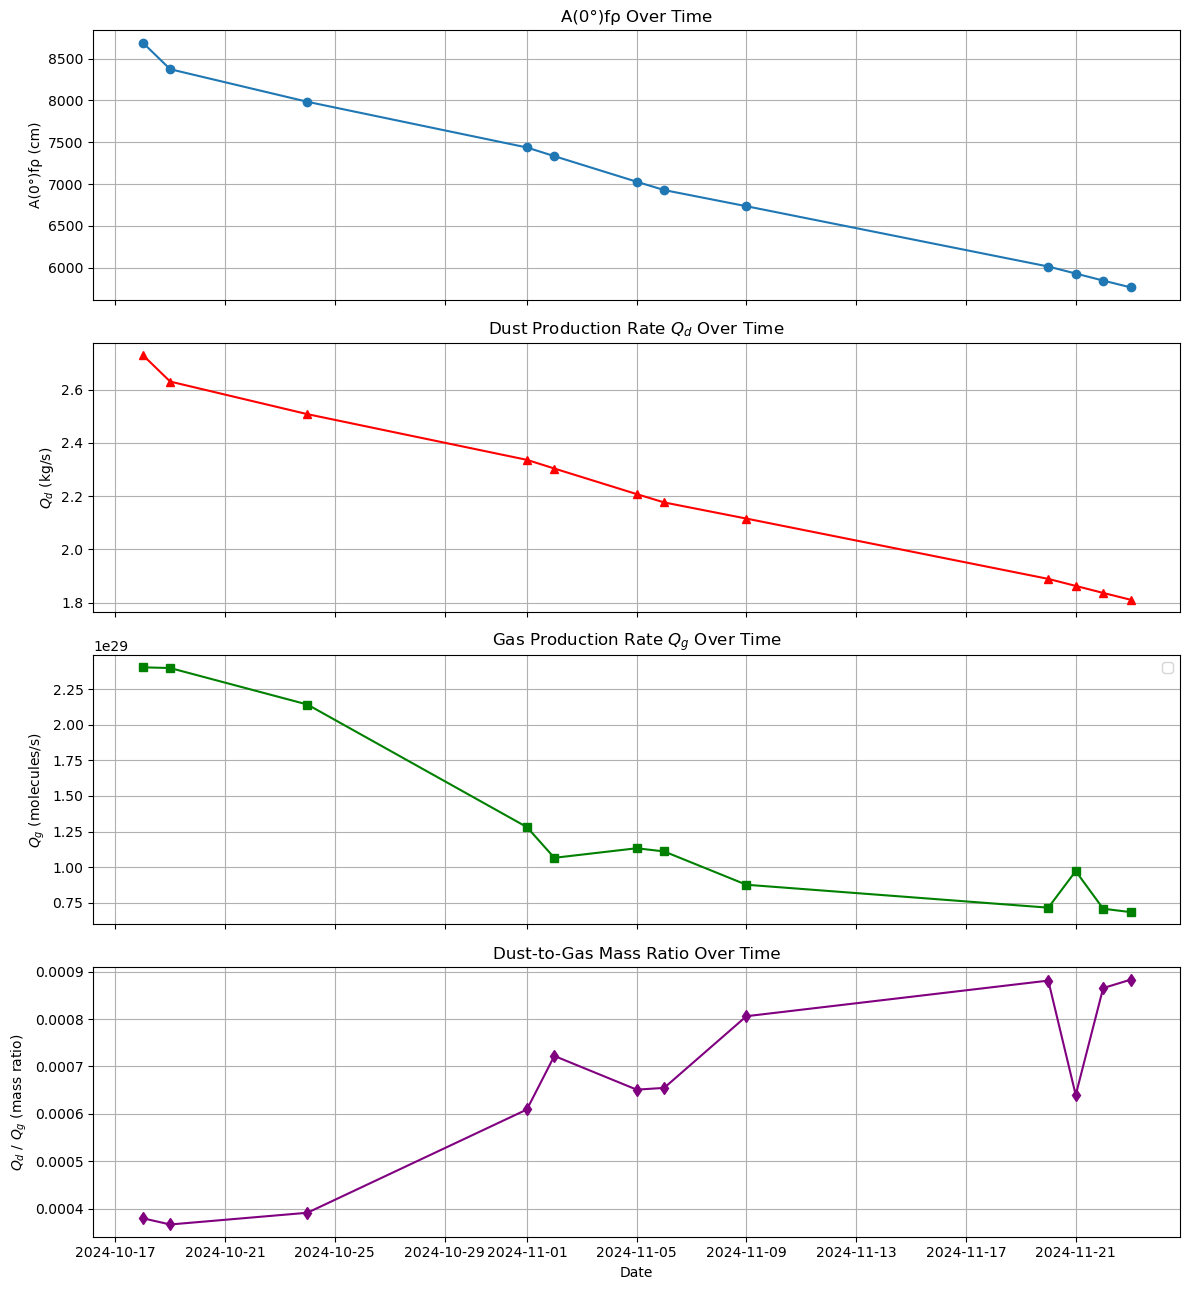

In [29]:
import numpy as np
import astropy.units as u
from sbpy.activity import Afrho
import pandas as pd
import matplotlib.pyplot as plt

# Define constants in CGS units
r_d = 1e-4 * u.cm         # 1 μm = 1e-4 cm
sigma_d = 1 * u.g / u.cm**3
v_d = 3e4 * u.cm / u.s    # 300 m/s
p_0 = 0.04                # dimensionless

# Load the data
data = np.loadtxt('Afrho_Phase_Angle.txt', skiprows=1)
phase_angles = data[:, 0] * u.deg
afrho_values = data[:, 1] * u.cm

# Corresponding observation dates
dates = pd.to_datetime([
    "2024-10-18", "2024-10-19", "2024-10-24", "2024-11-01",
    "2024-11-02", "2024-11-05", "2024-11-06", "2024-11-09",
    "2024-11-20", "2024-11-21", "2024-11-22", "2024-11-23"
])

# Precompute the physical multiplier (in g/s/cm)
multiplier = (4 * np.pi * r_d * sigma_d * v_d) / (3 * p_0)
multiplier = multiplier.to(u.g / (u.s * u.cm))  # Correct unit

# Compute A(0°)frho and Q_d
a0frho_values = []
Q_d_values = []

for pa, af in zip(phase_angles, afrho_values):
    af_obj = Afrho(af)
    a0frho = af_obj.to_phase(pa, 0 * u.deg)
    a0frho_values.append(a0frho.value)
    
    Q_d = (af_obj * multiplier/1e3).to(u.g / u.s)
    Q_d_values.append(Q_d.value)

# Create DataFrame
df = pd.DataFrame({
    "Date": dates,
    "Phase Angle (deg)": phase_angles.value,
    "Afρ (cm)": afrho_values.value,
    "A(0°)fρ (cm)": a0frho_values,
    "Q_d (kg/s)": Q_d_values
})

# --- Load geocentric distance (delta) and m_v from uploaded file ---
mag_data = np.genfromtxt('magnitude of c2023.txt', skip_header=1, dtype=str)

# Reformat dates to match df (e.g. "18/10" → "2024-10-18")
mag_dates = ["2024-" + d[3:] + "-" + d[:2] for d in mag_data[:, 0]]
mag_dates = pd.to_datetime(mag_dates)

# Extract delta and m_v
delta_au = mag_data[:, 1].astype(float)
m_v = mag_data[:, 2].astype(float)

# Compute log(Q_g) using the empirical formula
log_Qg_empirical = 30.675 - 0.2453 * (m_v - 5 * np.log10(delta_au))
Q_g_empirical = 10 ** log_Qg_empirical

# Add empirical Q_g to your DataFrame by matching dates
df["Q_g (molecules/s)"] = Q_g_empirical

# --- Compute Dust-to-Gas Mass Ratio ---
mass_per_h2o = (18.015 * u.g / u.mol) / (6.022e23 / u.mol)  # g/molecule
mass_per_h2o = mass_per_h2o.to(u.kg).value  # Convert to kg/molecule

# Convert Q_g from molecules/s to kg/s
Q_g_kg_s = df["Q_g (molecules/s)"] * mass_per_h2o

# Compute dust-to-gas ratio
dust_to_gas_ratio = df["Q_d (kg/s)"] / Q_g_kg_s

# --- Fourth subplot ---
fig, ax = plt.subplots(4, 1, figsize=(12, 13), sharex=True)

# A(0°)frho
ax[0].plot(df["Date"], df["Afρ (cm)"], marker='o')
ax[0].set_title("A(0°)fρ Over Time")
ax[0].set_ylabel("A(0°)fρ (cm)")
ax[0].grid(True)

# Q_d
ax[1].plot(df["Date"], df["Q_d (kg/s)"], marker='^', color='red')
ax[1].set_title(r"Dust Production Rate $Q_d$ Over Time")
ax[1].set_ylabel(r"$Q_d$ (kg/s)")
ax[1].grid(True)

# Q_g
ax[2].plot(df["Date"], df["Q_g (molecules/s)"], marker='s', color='green')
ax[2].set_title(r"Gas Production Rate $Q_g$ Over Time")
ax[2].set_ylabel(r"$Q_g$ (molecules/s)")
ax[2].legend()
ax[2].grid(True)

# Dust-to-Gas Ratio
ax[3].plot(df["Date"], dust_to_gas_ratio, marker='d', color='purple')
ax[3].set_title("Dust-to-Gas Mass Ratio Over Time")
ax[3].set_ylabel(r"$Q_d$ / $Q_g$ (mass ratio)")
ax[3].set_xlabel("Date")
ax[3].grid(True)
plt.savefig("/Users/kylerichardaffleck/Downloads/dust_ratio.pdf", dpi=300)
plt.tight_layout()
plt.show()



Empirical Gas Production Rates (Q_g) from Visual Magnitude:
2024-10-18: 2.402e+29 molecules/s
2024-10-19: 2.397e+29 molecules/s
2024-10-24: 2.142e+29 molecules/s
2024-11-01: 1.282e+29 molecules/s
2024-11-02: 1.066e+29 molecules/s
2024-11-05: 1.133e+29 molecules/s
2024-11-06: 1.111e+29 molecules/s
2024-11-09: 8.774e+28 molecules/s
2024-11-20: 7.167e+28 molecules/s
2024-11-21: 9.732e+28 molecules/s
2024-11-22: 7.094e+28 molecules/s
2024-11-23: 6.855e+28 molecules/s
Empirical Gas Production Rates (Q_g) from Visual Magnitude:
2024-10-18: 1.571e-06
2024-10-19: 1.481e-06
2024-10-24: 1.398e-06
2024-11-01: 1.127e-06
2024-11-02: 7.926e-07
2024-11-05: 7.624e-07
2024-11-06: 6.816e-07
2024-11-09: 6.340e-07
2024-11-20: 4.177e-07
2024-11-21: 4.067e-07
2024-11-22: 3.961e-07
2024-11-23: 3.861e-07
Empirical Gas Production Rates (Q_g) from Visual Magnitude:
2024-10-18: 1.122e+01
2024-10-19: 1.058e+01
2024-10-24: 9.983e+00
2024-11-01: 8.050e+00
2024-11-02: 5.661e+00
2024-11-05: 5.446e+00
2024-11-06: 4.86

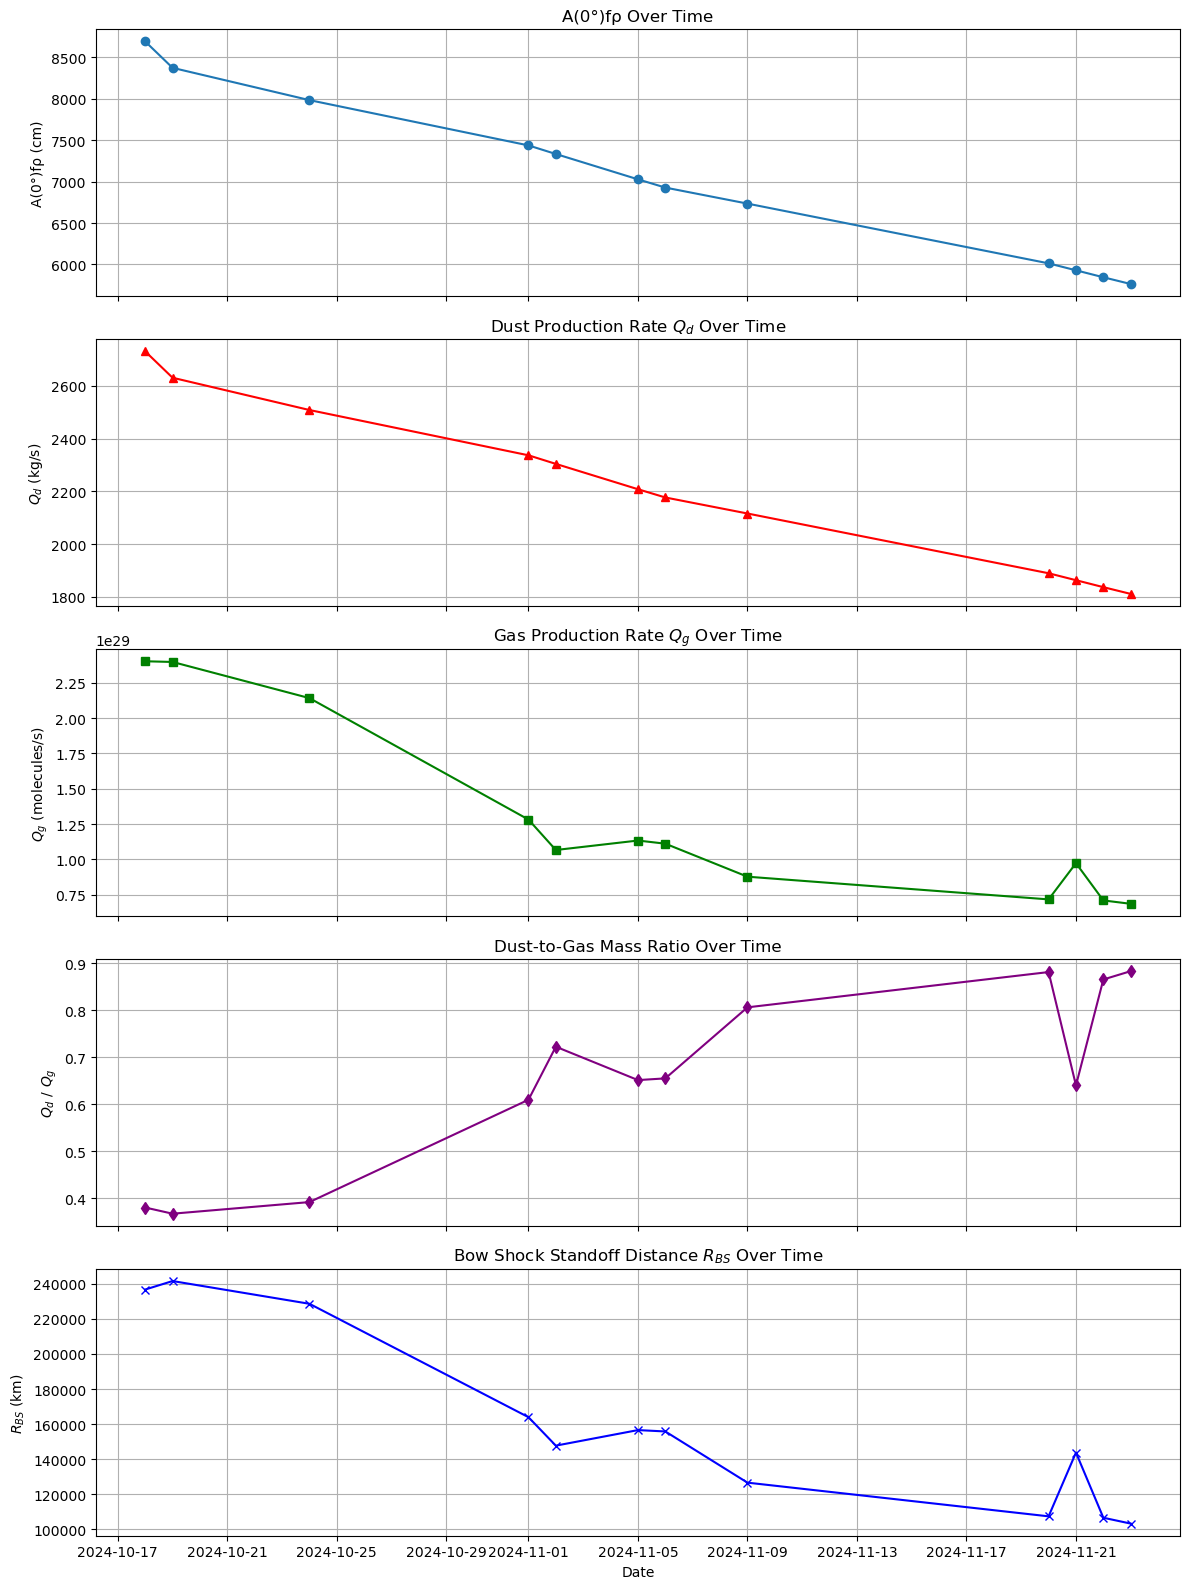


Dust-to-Gas Mass Ratio (Q_d / Q_g) per date:
2024-10-18: 3.799e-01
2024-10-19: 3.668e-01
2024-10-24: 3.915e-01
2024-11-01: 6.093e-01
2024-11-02: 7.222e-01
2024-11-05: 6.512e-01
2024-11-06: 6.548e-01
2024-11-09: 8.060e-01
2024-11-20: 8.811e-01
2024-11-21: 6.398e-01
2024-11-22: 8.653e-01
2024-11-23: 8.830e-01


In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sbpy.activity import Afrho
import astropy.units as u

# --- Constants ---
r_d = 1e-4 * u.cm
sigma_d = 1 * u.g / u.cm**3
v_d = 3e4 * u.cm / u.s
p_0 = 0.04
mass_per_h2o = (18.015 * u.g / u.mol) / (6.022e23 / u.mol)
mass_per_h2o = mass_per_h2o.to(u.kg).value

# --- Load Afρ, Phase Angle, Heliocentric distance ---
afrho_data = np.loadtxt("Afrho_Phase_Angle.txt", skiprows=1)
phase_angles = afrho_data[:, 0] * u.deg
afrho_values = afrho_data[:, 1] * u.cm
r_h_au = afr_h = afrho_data[:, 2]

# --- Observation dates ---
dates = pd.to_datetime([
    "2024-10-18", "2024-10-19", "2024-10-24", "2024-11-01",
    "2024-11-02", "2024-11-05", "2024-11-06", "2024-11-09",
    "2024-11-20", "2024-11-21", "2024-11-22", "2024-11-23"
])

# --- Load magnitude data ---
mag_data = np.genfromtxt("magnitude of c2023.txt", skip_header=1, dtype=str)
mag_dates = ["2024-" + d[3:] + "-" + d[:2] for d in mag_data[:, 0]]
mag_dates = pd.to_datetime(mag_dates)
delta_au = mag_data[:, 1].astype(float)
m_v = mag_data[:, 2].astype(float)

# --- Compute Q_d ---
multiplier = (4 * np.pi * r_d * sigma_d * v_d / (3 * p_0)).to(u.g / (u.s * u.cm))
a0frho_values = []
Q_d_values = []

for pa, af in zip(phase_angles, afrho_values):
    af_obj = Afrho(af)
    a0frho = af_obj.to_phase(pa, 0 * u.deg)
    a0frho_values.append(a0frho.value)
    Q_d = (af_obj * multiplier / 1e3).to(u.g / u.s)
    Q_d_values.append(Q_d.value)

# --- Compute empirical Q_g from magnitude and convert to kg/s ---
log_Qg_empirical = 30.675 - 0.2453 * (m_v - 5 * np.log10(delta_au))
Q_g_empirical = 10 ** log_Qg_empirical
Q_g_kg_s = Q_g_empirical * mass_per_h2o

print("Empirical Gas Production Rates (Q_g) from Visual Magnitude:")
for date, qg in zip(mag_dates, Q_g_empirical):
    print(f"{date.strftime('%Y-%m-%d')}: {qg:.3e} molecules/s")

# --- Scale ionization rate and solar wind density with heliocentric distance ---
nu_1AU = 7e-7  # s^-1
n_sw_1AU = 5   # cm^-3
nu_scaled = nu_1AU * (1 / r_h_au)**2
n_sw_scaled_cm3 = n_sw_1AU * (1 / r_h_au)**2
n_sw_scaled_m3 = n_sw_scaled_cm3 * 1e6  # to m^-3
print("Empirical Gas Production Rates (Q_g) from Visual Magnitude:")
for date, nu in zip(mag_dates, nu_scaled):
    print(f"{date.strftime('%Y-%m-%d')}: {nu:.3e}")
print("Empirical Gas Production Rates (Q_g) from Visual Magnitude:")
for date, n_sw in zip(mag_dates, n_sw_scaled_cm3):
    print(f"{date.strftime('%Y-%m-%d')}: {n_sw:.3e}")
# --- Bow shock constants ---
u_n = 1e3  # m/s
u_sw = 4e5  # m/s
m_i = 17 * 1.66e-27  # kg
m_sw = 1.67e-27      # kg
rho_ux_crit = 1.3

R_n = 6000  # Comet nucleus radius in meters

# Compute A for each date
numerator_A = nu_scaled * Q_g_empirical * m_i
denominator_A = 4 * np.pi * u_n * n_sw_scaled_m3 * m_sw * u_sw
A_correction = (numerator_A / denominator_A) * (1/((u_n / nu_scaled) + R_n))

# Compute R_BS including A
R_BS_with_A = (numerator_A) / (
    4 * np.pi * u_n * n_sw_scaled_m3 * m_sw * u_sw * ((rho_ux_crit - 1) + (A_correction))
)
R_BS_km = R_BS_with_A / 1e3  # in km
# --- Compile everything into a DataFrame ---
df = pd.DataFrame({
    "Date": dates,
    "Phase Angle (deg)": phase_angles.value,
    "Afρ (cm)": afrho_values.value,
    "A(0°)fρ (cm)": a0frho_values,
    "Q_d (kg/s)": Q_d_values,
    "Delta (AU)": delta_au,
    "m_v": m_v,
    "Q_g (molecules/s)": Q_g_empirical,
    "Q_g (kg/s)": Q_g_kg_s,
    "Dust-to-Gas Ratio": np.array(Q_d_values) / Q_g_kg_s,
    "r_h (AU)": r_h_au,
    "R_BS (km)": R_BS_km
})

# --- Plotting all in 5 subplots ---
fig, ax = plt.subplots(5, 1, figsize=(12, 16), sharex=True)

# A(0°)frho
ax[0].plot(df["Date"], df["Afρ (cm)"], marker='o')
ax[0].set_title("A(0°)fρ Over Time")
ax[0].set_ylabel("A(0°)fρ (cm)")
ax[0].grid(True)

# Q_d
ax[1].plot(df["Date"], df["Q_d (kg/s)"], marker='^', color='red')
ax[1].set_title(r"Dust Production Rate $Q_d$ Over Time")
ax[1].set_ylabel(r"$Q_d$ (kg/s)")
ax[1].grid(True)

# Q_g
ax[2].plot(df["Date"], df["Q_g (molecules/s)"], marker='s', color='green')
ax[2].set_title(r"Gas Production Rate $Q_g$ Over Time")
ax[2].set_ylabel(r"$Q_g$ (molecules/s)")
ax[2].grid(True)

# Dust-to-Gas Ratio
ax[3].plot(df["Date"], df["Dust-to-Gas Ratio"], marker='d', color='purple')
ax[3].set_title("Dust-to-Gas Mass Ratio Over Time")
ax[3].set_ylabel(r"$Q_d$ / $Q_g$")
ax[3].grid(True)

# Bow Shock Distance
ax[4].plot(df["Date"], df["R_BS (km)"], marker='x', color='blue')
ax[4].set_title(r"Bow Shock Standoff Distance $R_{BS}$ Over Time")
ax[4].set_ylabel(r"$R_{BS}$ (km)")
ax[4].set_xlabel("Date")
ax[4].grid(True)

plt.tight_layout()
plt.savefig("/Users/kylerichardaffleck/Downloads/dust_gas_bowshock.pdf", dpi=300)
plt.show()
print("\nDust-to-Gas Mass Ratio (Q_d / Q_g) per date:")
for date, ratio in zip(df["Date"], df["Dust-to-Gas Ratio"]):
    print(f"{date.strftime('%Y-%m-%d')}: {ratio:.3e}")

Empirical Gas Production Rates (Q_g) from Visual Magnitude:
2024-10-18: 2.402e+29 molecules/s
2024-10-19: 2.397e+29 molecules/s
2024-10-24: 2.142e+29 molecules/s
2024-11-01: 1.282e+29 molecules/s
2024-11-02: 1.066e+29 molecules/s
2024-11-05: 1.133e+29 molecules/s
2024-11-06: 1.111e+29 molecules/s
2024-11-09: 8.774e+28 molecules/s
2024-11-20: 7.167e+28 molecules/s
2024-11-21: 9.732e+28 molecules/s
2024-11-22: 7.094e+28 molecules/s
2024-11-23: 6.855e+28 molecules/s
Empirical Gas Production Rates (Q_g) from Visual Magnitude:
2024-10-18: 1.571e-06
2024-10-19: 1.481e-06
2024-10-24: 1.398e-06
2024-11-01: 1.127e-06
2024-11-02: 7.926e-07
2024-11-05: 7.624e-07
2024-11-06: 6.816e-07
2024-11-09: 6.340e-07
2024-11-20: 4.177e-07
2024-11-21: 4.067e-07
2024-11-22: 3.961e-07
2024-11-23: 3.861e-07
Empirical Gas Production Rates (Q_g) from Visual Magnitude:
2024-10-18: 1.122e+01
2024-10-19: 1.058e+01
2024-10-24: 9.983e+00
2024-11-01: 8.050e+00
2024-11-02: 5.661e+00
2024-11-05: 5.446e+00
2024-11-06: 4.86

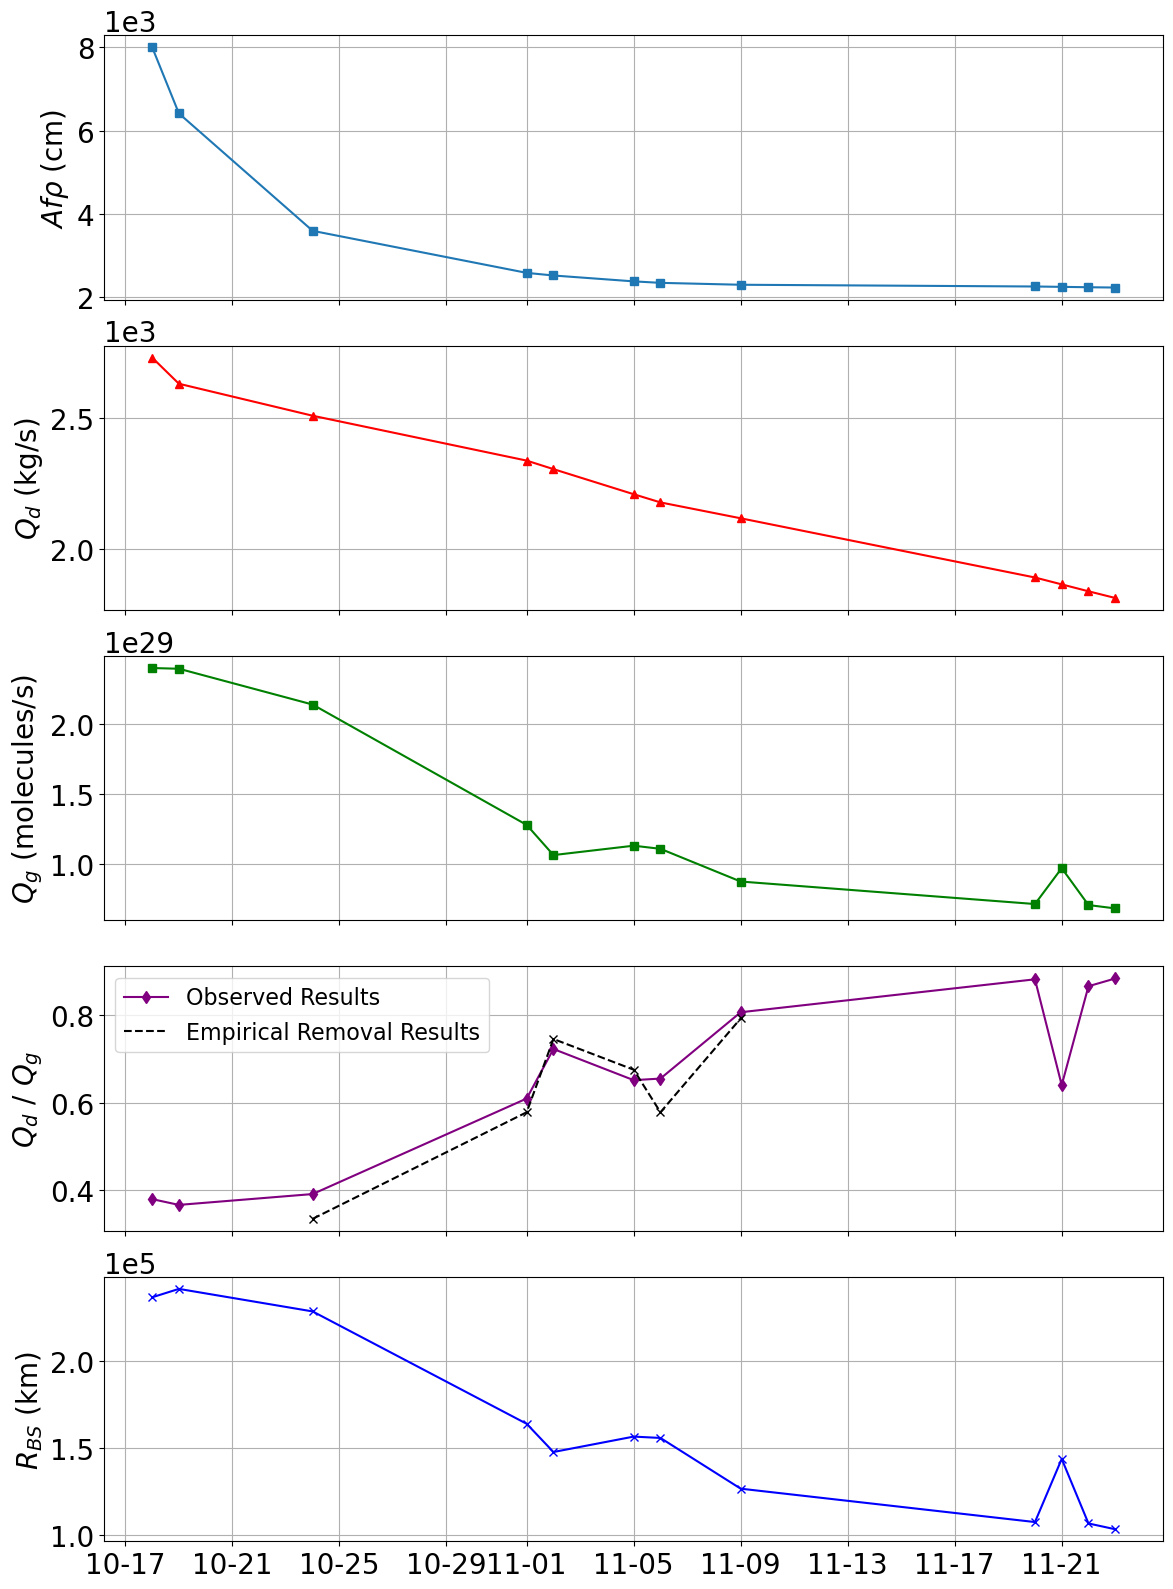


Dust-to-Gas Mass Ratio (Q_d / Q_g) per date:
2024-10-18: 3.799e-01
2024-10-19: 3.668e-01
2024-10-24: 3.915e-01
2024-11-01: 6.093e-01
2024-11-02: 7.222e-01
2024-11-05: 6.512e-01
2024-11-06: 6.548e-01
2024-11-09: 8.060e-01
2024-11-20: 8.811e-01
2024-11-21: 6.398e-01
2024-11-22: 8.653e-01
2024-11-23: 8.830e-01


In [169]:

# A(0°)frho
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sbpy.activity import Afrho
import astropy.units as u
import matplotlib.dates as mdates

# --- Constants ---
r_d = 1e-4 * u.cm
sigma_d = 1 * u.g / u.cm**3
v_d = 3e4 * u.cm / u.s
p_0 = 0.04
mass_per_h2o = (18.015 * u.g / u.mol) / (6.022e23 / u.mol)
mass_per_h2o = mass_per_h2o.to(u.kg).value

# --- Load Afρ, Phase Angle, Heliocentric distance ---
afrho_data = np.loadtxt("Afrho_Phase_Angle.txt", skiprows=1)
phase_angles = afrho_data[:, 0] * u.deg
afrho_values = afrho_data[:, 1] * u.cm
r_h_au = afr_h = afrho_data[:, 2]

# --- Observation dates ---
dates = pd.to_datetime([
    "2024-10-18", "2024-10-19", "2024-10-24", "2024-11-01",
    "2024-11-02", "2024-11-05", "2024-11-06", "2024-11-09",
    "2024-11-20", "2024-11-21", "2024-11-22", "2024-11-23"
])

# --- Load magnitude data ---
mag_data = np.genfromtxt("magnitude of c2023.txt", skip_header=1, dtype=str)
mag_dates = ["2024-" + d[3:] + "-" + d[:2] for d in mag_data[:, 0]]
mag_dates = pd.to_datetime(mag_dates)
delta_au = mag_data[:, 1].astype(float)
m_v = mag_data[:, 2].astype(float)

# --- Compute Q_d ---
multiplier = (4 * np.pi * r_d * sigma_d * v_d / (3 * p_0)).to(u.g / (u.s * u.cm))
a0frho_values = []
Q_d_values = []

for pa, af in zip(phase_angles, afrho_values):
    af_obj = Afrho(af)
    a0frho = af_obj.to_phase(pa, 0 * u.deg)
    a0frho_values.append(a0frho.value)
    Q_d = (af_obj * multiplier / 1e3).to(u.g / u.s)
    Q_d_values.append(Q_d.value)

# --- Compute empirical Q_g from magnitude and convert to kg/s ---
log_Qg_empirical = 30.675 - 0.2453 * (m_v - 5 * np.log10(delta_au))
Q_g_empirical = 10 ** log_Qg_empirical
Q_g_kg_s = Q_g_empirical * mass_per_h2o

print("Empirical Gas Production Rates (Q_g) from Visual Magnitude:")
for date, qg in zip(mag_dates, Q_g_empirical):
    print(f"{date.strftime('%Y-%m-%d')}: {qg:.3e} molecules/s")

# --- Scale ionization rate and solar wind density with heliocentric distance ---
nu_1AU = 7e-7  # s^-1
n_sw_1AU = 5   # cm^-3
nu_scaled = nu_1AU * (1 / r_h_au)**2
n_sw_scaled_cm3 = n_sw_1AU * (1 / r_h_au)**2
n_sw_scaled_m3 = n_sw_scaled_cm3 * 1e6  # to m^-3
print("Empirical Gas Production Rates (Q_g) from Visual Magnitude:")
for date, nu in zip(mag_dates, nu_scaled):
    print(f"{date.strftime('%Y-%m-%d')}: {nu:.3e}")
print("Empirical Gas Production Rates (Q_g) from Visual Magnitude:")
for date, n_sw in zip(mag_dates, n_sw_scaled_cm3):
    print(f"{date.strftime('%Y-%m-%d')}: {n_sw:.3e}")
# --- Bow shock constants ---
u_n = 1e3  # m/s
u_sw = 4e5  # m/s
m_i = 17 * 1.66e-27  # kg
m_sw = 1.67e-27      # kg
rho_ux_crit = 1.3

R_n = 3000  # Comet nucleus radius in meters

# Compute A for each date
numerator_A = nu_scaled * Q_g_empirical * m_i
denominator_A = 4 * np.pi * u_n * n_sw_scaled_m3 * m_sw * u_sw
A_correction = (numerator_A / denominator_A) * (1/((u_n / nu_scaled) + R_n))

# Compute R_BS including A
R_BS_with_A = (numerator_A) / (
    4 * np.pi * u_n * n_sw_scaled_m3 * m_sw * u_sw * ((rho_ux_crit - 1) + (A_correction))
)
R_BS_km = R_BS_with_A / 1e3  # in km
# --- Compile everything into a DataFrame ---
df = pd.DataFrame({
    "Date": dates,
    "Phase Angle (deg)": phase_angles.value,
    "Afρ (cm)": afrho_values.value,
    "A(0°)fρ (cm)": a0frho_values,
    "Q_d (kg/s)": Q_d_values,
    "Delta (AU)": delta_au,
    "m_v": m_v,
    "Q_g (molecules/s)": Q_g_empirical,
    "Q_g (kg/s)": Q_g_kg_s,
    "Dust-to-Gas Ratio": np.array(Q_d_values) / Q_g_kg_s,
    "r_h (AU)": r_h_au,
    "R_BS (km)": R_BS_km
})
    

# --- Plotting all in 5 subplots ---
fig, ax = plt.subplots(5, 1, figsize=(12, 16), sharex=True)

# A(0°)frho
ax[0].plot(df["Date"], df["A(0°)fρ (cm)"], marker='s', linestyle='-', label=r"Corrected $A(0^\circ)f\rho$")
#ax[0].set_title("A(0°)fρ Over Time")
ax[0].set_ylabel(r"$Af\rho$ (cm)",fontsize=20)
ax[0].tick_params(axis='y',labelsize=20)
ax[0].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))  # <-- Scientific notation
ax[0].yaxis.get_offset_text().set_fontsize(20) 
ax[0].grid(True)

# Q_d
ax[1].plot(df["Date"], df["Q_d (kg/s)"], marker='^', color='red')
#ax[1].set_title(r"Dust Production Rate $Q_d$ Over Time")
ax[1].set_ylabel(r"$Q_d$ (kg/s)",fontsize=20)
ax[1].tick_params(axis='y',labelsize=20)
ax[1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))  # <-- Scientific notation
ax[1].yaxis.get_offset_text().set_fontsize(20) 
ax[1].grid(True)

# Q_g
ax[2].plot(df["Date"], df["Q_g (molecules/s)"], marker='s', color='green')
#ax[2].set_title(r"Gas Production Rate $Q_g$ Over Time")
ax[2].set_ylabel(r"$Q_g$ (molecules/s)",fontsize=20)
ax[2].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax[2].yaxis.get_offset_text().set_fontsize(20)
ax[2].tick_params(axis='y',labelsize=20)
ax[2].grid(True)

# Dust-to-Gas Ratio
observed_line = ax[3].plot(df["Date"], df["Dust-to-Gas Ratio"], marker='d', color='purple', label="Observed Results")
ax[3].tick_params(axis='y', labelsize=20)
ax[3].grid(True)

manual_ratios = {
    "2024-10-24": 0.335,
    "2024-11-01": 0.578,
    "2024-11-02": 0.745,
    "2024-11-05": 0.675,
    "2024-11-06": 0.578,
    "2024-11-09": 0.792
}

# Extract dates and values, then sort them by date
sorted_dates = sorted(manual_ratios.keys())
manual_dates = [pd.to_datetime(d) for d in sorted_dates]
manual_values = [manual_ratios[d] for d in sorted_dates]

# Plot the points and connecting line
computed_points = ax[3].plot(manual_dates, manual_values, 'x', color='black', zorder=5)
computed_line = ax[3].plot(manual_dates, manual_values, linestyle='--', color='black', linewidth=1.5, label="Empirical Removal Results")

# Add legend
ax[3].legend(fontsize=16)
ax[3].set_ylabel(r"$Q_d$ / $Q_g$", fontsize=20)

# Bow Shock Distance
ax[4].plot(df["Date"], df["R_BS (km)"], marker='x', color='blue')
ax[4].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax[4].set_ylabel(r"$R_{BS}$ (km)", fontsize=20)
ax[4].tick_params(axis='both', labelsize=20)
ax[4].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))  # <-- Scientific notation
ax[4].yaxis.get_offset_text().set_fontsize(20)                   # <-- Match font size
ax[4].grid(True)

plt.tight_layout()
plt.savefig("/Users/kylerichardaffleck/Downloads/dust_gas_bowshock.pdf", dpi=300)
plt.show()
print("\nDust-to-Gas Mass Ratio (Q_d / Q_g) per date:")
for date, ratio in zip(df["Date"], df["Dust-to-Gas Ratio"]):
    print(f"{date.strftime('%Y-%m-%d')}: {ratio:.3e}")